# Introduction
Flight ticket prices can be something hard to guess, today we might see a price, check out the price of the same flight tomorrow, it will be a different story. We might have often heard travellers saying that flight ticket prices are so unpredictable.

Here you will be provided with prices of flight tickets for various airlines between the months of March and June of 2026 and between various cities. Size of training set: 10683 records size of test set 2671 records Feartures: Airline: The name of the airline.

Date_of_Journey. The date of the journey Source: The source from which the service ends. Route: The route taken by the flight to reach the destination. Duration: Total duration of the flight. Total_Stops: Total stops between the source and destination.

# Problem Statement
Build a Machine Learning Model to predict flight ticket fare for different airline.

# Loading the Data

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import KFold
from sklearn.linear_model import LassoCV ,  RidgeCV, ElasticNet, Lasso, Ridge
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error
import datetime
from mlxtend.regressor import StackingCVRegressor
from sklearn.kernel_ridge import KernelRidge
from sklearn.ensemble import RandomForestRegressor
from scipy.stats import skew
from scipy.special import boxcox1p
from scipy.stats import boxcox_normmax

# Data Cleaning & Preprocessing

In [8]:
train=pd.read_excel('/content/drive/MyDrive/Flight_Price/Data_Train.xlsx')
test=pd.read_excel('/content/drive/MyDrive/Flight_Price/Test_set.xlsx')

In [63]:
pd.set_option('display.max_columns', None)

In [9]:
train.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [10]:
train.info()
train.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


,Price
count,10683.000000
mean,9087.064121
std,4611.359167
min,1759.000000
25%,5277.000000
50%,8372.000000
75%,12373.000000
max,79512.000000


In [11]:
test.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info
0,Jet Airways,6/06/2019,Delhi,Cochin,DEL → BOM → COK,17:30,04:25 07 Jun,10h 55m,1 stop,No info
1,IndiGo,12/05/2019,Kolkata,Banglore,CCU → MAA → BLR,06:20,10:20,4h,1 stop,No info
2,Jet Airways,21/05/2019,Delhi,Cochin,DEL → BOM → COK,19:15,19:00 22 May,23h 45m,1 stop,In-flight meal not included
3,Multiple carriers,21/05/2019,Delhi,Cochin,DEL → BOM → COK,08:00,21:00,13h,1 stop,No info
4,Air Asia,24/06/2019,Banglore,Delhi,BLR → DEL,23:55,02:45 25 Jun,2h 50m,non-stop,No info


In [12]:
test.info()
test.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2671 entries, 0 to 2670
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          2671 non-null   object
 1   Date_of_Journey  2671 non-null   object
 2   Source           2671 non-null   object
 3   Destination      2671 non-null   object
 4   Route            2671 non-null   object
 5   Dep_Time         2671 non-null   object
 6   Arrival_Time     2671 non-null   object
 7   Duration         2671 non-null   object
 8   Total_Stops      2671 non-null   object
 9   Additional_Info  2671 non-null   object
dtypes: object(10)
memory usage: 208.8+ KB


,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info
count,2671,2671,2671,2671,2671,2671,2671,2671,2671,2671
unique,11,44,5,6,100,199,704,320,5,6
top,Jet Airways,9/05/2019,Delhi,Cochin,DEL → BOM → COK,10:00,19:00,2h 50m,1 stop,No info
freq,897,144,1145,1145,624,62,113,122,1431,2148


In [13]:
len_train=train.shape[0]

In [14]:
for i in train.columns:
  print("Unique Values in", i, train[i].nunique())

Unique Values in Airline 12
Unique Values in Date_of_Journey 44
Unique Values in Source 5
Unique Values in Destination 6
Unique Values in Route 128
Unique Values in Dep_Time 222
Unique Values in Arrival_Time 1343
Unique Values in Duration 368
Unique Values in Total_Stops 5
Unique Values in Additional_Info 10
Unique Values in Price 1870


In [15]:
for i in test.columns:
  print("Unique Values in", i, test[i].nunique())

Unique Values in Airline 11
Unique Values in Date_of_Journey 44
Unique Values in Source 5
Unique Values in Destination 6
Unique Values in Route 100
Unique Values in Dep_Time 199
Unique Values in Arrival_Time 704
Unique Values in Duration 320
Unique Values in Total_Stops 5
Unique Values in Additional_Info 6


In [20]:
#coalescing the two columns for data treatment
train = pd.concat([train, test], axis=0).reset_index(drop=True)

/tmp/ipykernel_6835/817612757.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train, x="Airline", y="Price", palette="Set2")


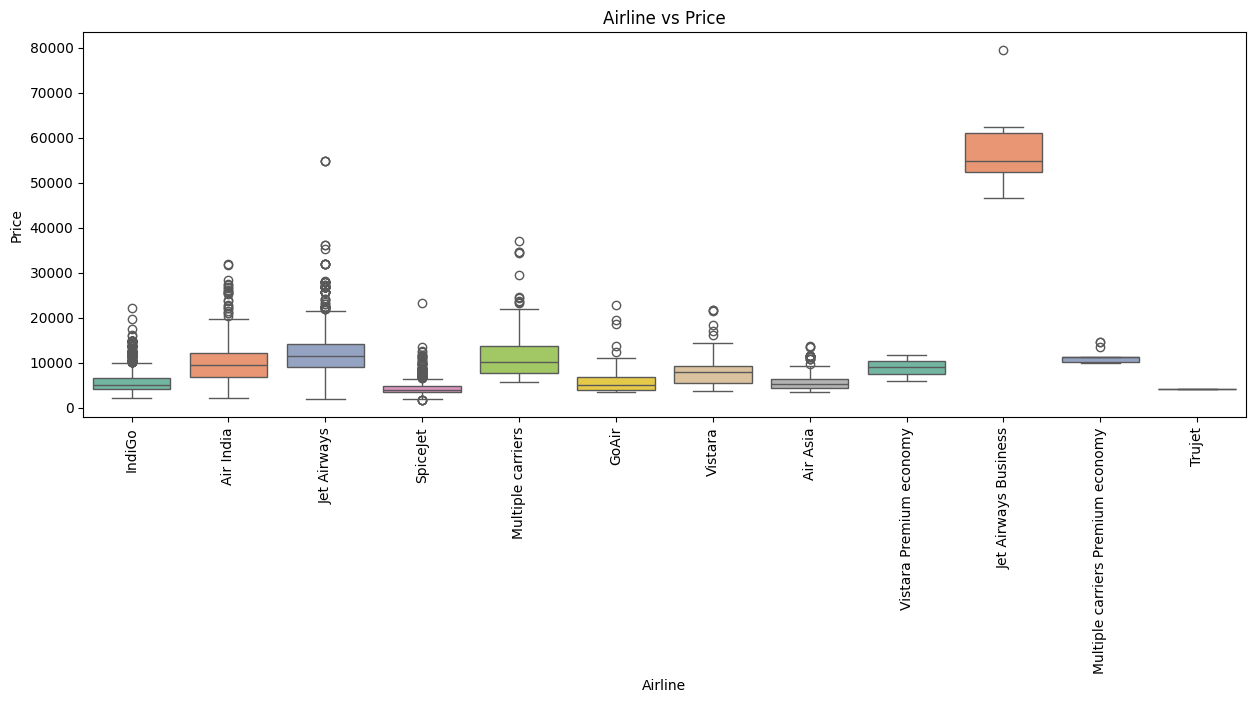

/tmp/ipykernel_6835/817612757.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train, x="Total_Stops", y="Price", palette="Set3")


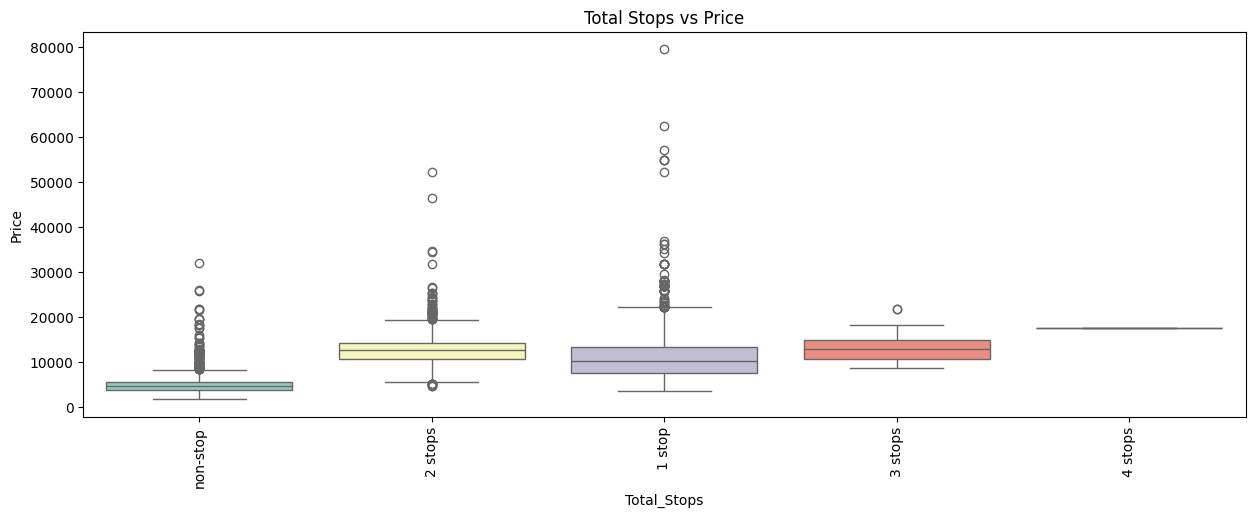

/tmp/ipykernel_6835/817612757.py:22: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  train["Date_of_Journey"] = pd.to_datetime(train["Date_of_Journey"])


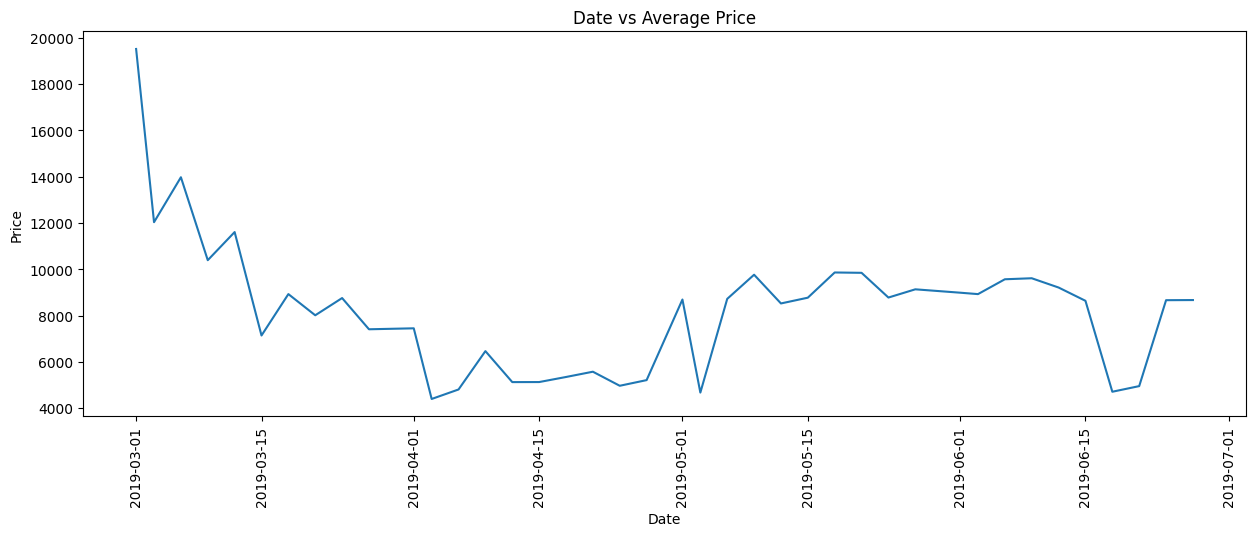

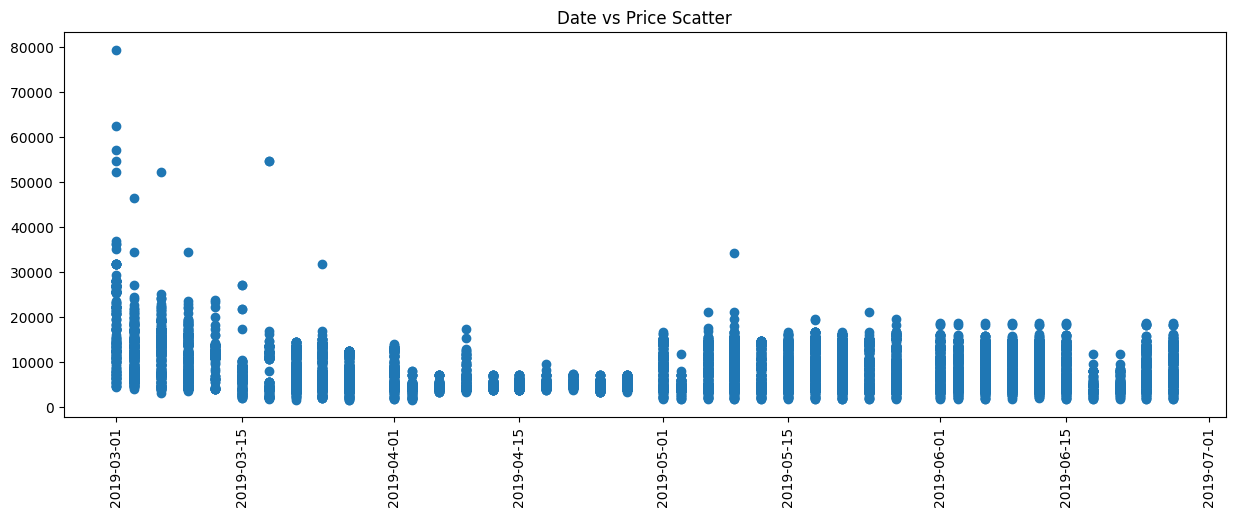

/tmp/ipykernel_6835/817612757.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train, x="Source", y="Price", palette="coolwarm")


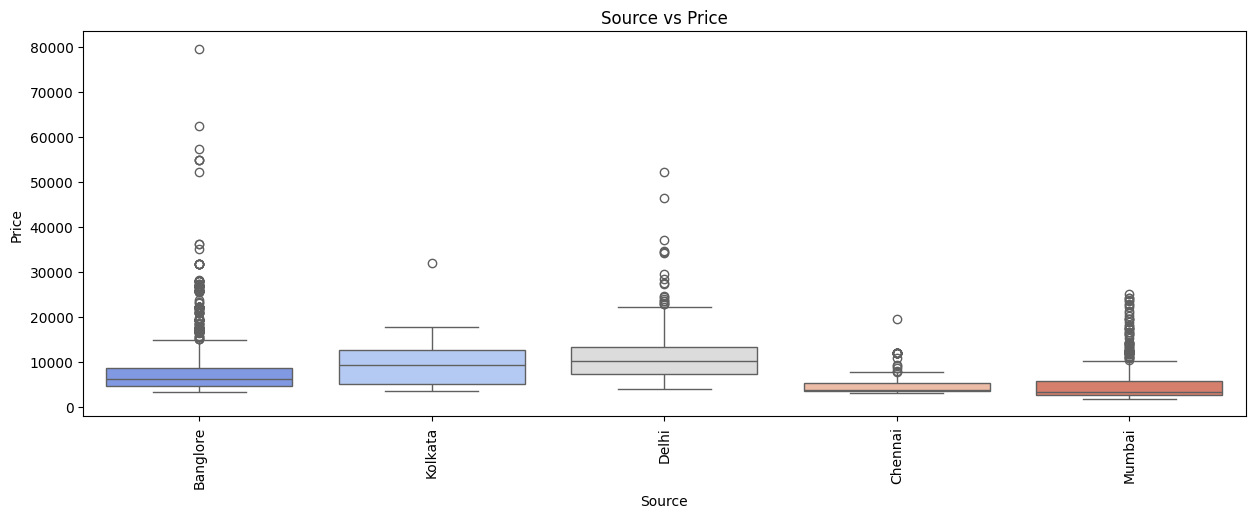

/tmp/ipykernel_6835/817612757.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train, x="Destination", y="Price", palette="husl")


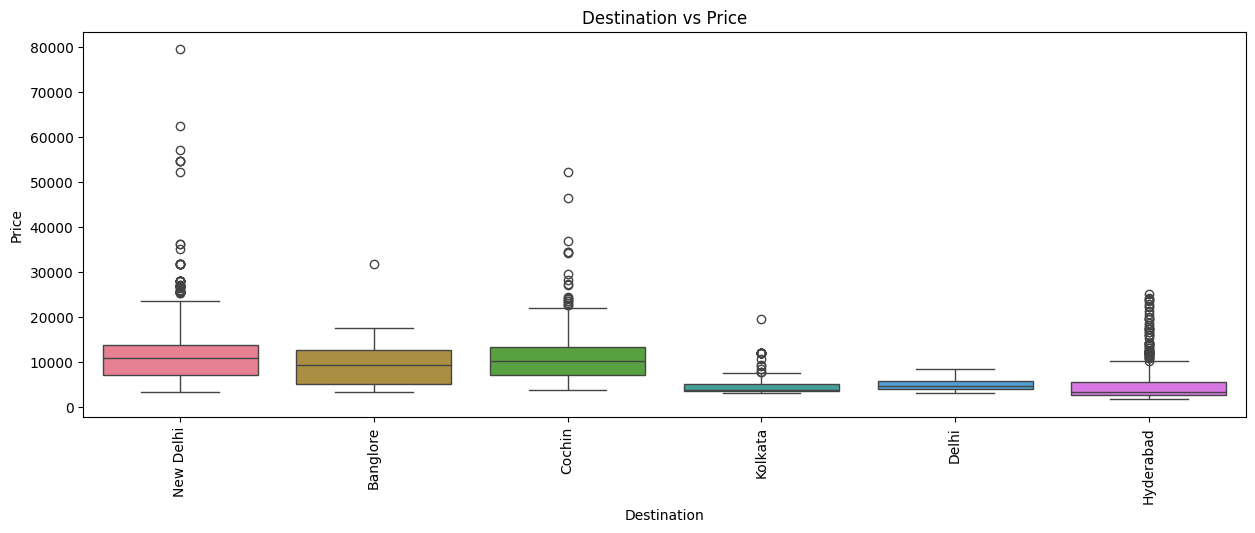

/tmp/ipykernel_6835/817612757.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train, x="Additional_Info", y="Price", palette="Set1")


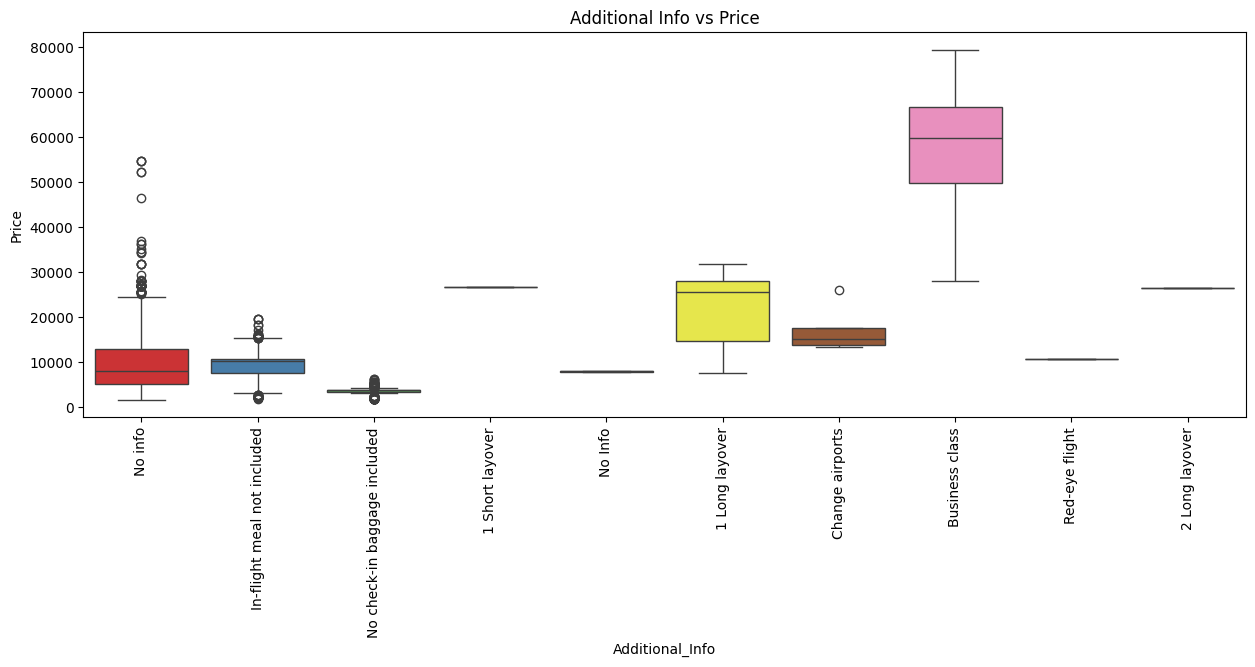

In [24]:
# -----------------------------
# Airline vs Price
# -----------------------------
plt.figure(figsize=(15,5))
plt.xticks(rotation=90)
sns.boxplot(data=train, x="Airline", y="Price", palette="Set2")
plt.title("Airline vs Price")
plt.show()

# -----------------------------
# Total Stops vs Price
# -----------------------------
plt.figure(figsize=(15,5))
plt.xticks(rotation=90)
sns.boxplot(data=train, x="Total_Stops", y="Price", palette="Set3")
plt.title("Total Stops vs Price")
plt.show()

# -----------------------------
# Date_of_Journey vs Price (line plot)
# -----------------------------
train["Date_of_Journey"] = pd.to_datetime(train["Date_of_Journey"])

plt.figure(figsize=(15,5))
plt.xticks(rotation=90)

temp = train.groupby("Date_of_Journey")["Price"].mean().reset_index()
plt.plot(temp["Date_of_Journey"], temp["Price"])

plt.title("Date vs Average Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

# -----------------------------
# Date_of_Journey vs Price (scatter)
# -----------------------------
plt.figure(figsize=(15,5))
plt.xticks(rotation=90)
plt.scatter(train["Date_of_Journey"], train["Price"])
plt.title("Date vs Price Scatter")
plt.show()

# -----------------------------
# Source vs Price
# -----------------------------
plt.figure(figsize=(15,5))
plt.xticks(rotation=90)
sns.boxplot(data=train, x="Source", y="Price", palette="coolwarm")
plt.title("Source vs Price")
plt.show()

# -----------------------------
# Destination vs Price
# -----------------------------
plt.figure(figsize=(15,5))
plt.xticks(rotation=90)
sns.boxplot(data=train, x="Destination", y="Price", palette="husl")
plt.title("Destination vs Price")
plt.show()

# -----------------------------
# Additional Info vs Price
# -----------------------------
plt.figure(figsize=(15,5))
plt.xticks(rotation=90)
sns.boxplot(data=train, x="Additional_Info", y="Price", palette="Set1")
plt.title("Additional Info vs Price")
plt.show()

# Feature Engineering

In [25]:
train['Depart_Time_Hour']=pd.to_datetime(train.Dep_Time).dt.hour
train['Depart_Time_Minutes']= pd.to_datetime(train.Dep_Time).dt.minute

train['Arr_Time_Hour']=pd.to_datetime(train.Arrival_Time).dt.hour
train['Arr_Time_Minutes']= pd.to_datetime(train.Arrival_Time).dt.minute

/tmp/ipykernel_6835/3069840751.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  train['Depart_Time_Hour']=pd.to_datetime(train.Dep_Time).dt.hour
/tmp/ipykernel_6835/3069840751.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  train['Depart_Time_Minutes']= pd.to_datetime(train.Dep_Time).dt.minute
/tmp/ipykernel_6835/3069840751.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  train['Arr_Time_Hour']=pd.to_datetime(train.Arrival_Time).dt.hour
/tmp/ipykernel_6835/3069840751.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling ba

In [26]:
#Converting Dep_Time from object (string) to time format
train['Dep_Time'] = pd.to_datetime(train.Dep_Time, format= "%H:%M").dt.time

In [27]:
#String manipulation to extract only hours and minutes from arrival_time column and dropping the data part, then
#converting the string to time format as done above
train.Arrival_Time = train.Arrival_Time.str.slice(0,6)
train.Arrival_Time = train.Arrival_Time.str.strip()
train.Arrival_Time = pd.to_datetime(train.Arrival_Time, format= "%H:%M").dt.time

In [28]:
#Converting date of journey to date fromat
train.Date_of_Journey = pd.to_datetime(train.Date_of_Journey, format= "%d/%m/%Y").dt.date

In [29]:
#Converting duration from string to integer value in minutes
minute=train['Duration'].str.slice(3,).str.extract('(\d+)')
hour=train['Duration'].str.extract('(\d+)').astype('int')
minute=minute.fillna(0)
train['Duration']=minute.astype('int')+hour*60


<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_6835/1854474539.py:2: SyntaxWarning: invalid escape sequence '\d'
  minute=train['Duration'].str.slice(3,).str.extract('(\d+)')
/tmp/ipykernel_6835/1854474539.py:3: SyntaxWarning: invalid escape sequence '\d'
  hour=train['Duration'].str.extract('(\d+)').astype('int')


In [31]:
#Creating column date of arrival by adding date and time of journey with duration in minutes
train['Date_of_Arrival'] = train.apply(
    lambda r: pd.Timestamp.combine(r['Date_of_Journey'], r['Arrival_Time']),
    axis=1
) + pd.to_timedelta(train["Duration"], unit='m')
train['Date_of_Arrival'] = train.Date_of_Arrival.dt.date

In [32]:
#Changing Total Stops from a string value to a categorical value
train.Total_Stops.value_counts()

,count
Total_Stops,
1 stop,7056
non-stop,4340
2 stops,1899
3 stops,56
4 stops,2


In [33]:
dic={'non-stop':0, '2 stops':2, '1 stop':1, '3 stops':3, '4 stops':4}
train['Total_Stops']=train['Total_Stops'].map(dic)
train.Total_Stops=train.Total_Stops.astype('category')

In [34]:
#Creating a column a categorical column class from the column Airline
r=train.Airline.str.split(' ',expand=True).get(2)
d={None:'Economy','Premium': 'Premium Economy', 'economy': 'Premium Economy', 'Business': 'Business'}
r=r.map(d)
train['Class']=r
train.Class=train.Class.astype('category')

In [35]:
# The column Additional info had values No info and No Info stored, editing to bring them to the same string value
train.loc[train.Additional_Info=='No Info','Additional_Info']='No Info'

In [36]:
#Creating an integer column same_day_travel that highlights whether the flight was arrived the same day, a day from
train['Same_day_travel']=train.Date_of_Arrival-train.Date_of_Journey
train['Same_day_travel']=train.Same_day_travel.astype('category')

In [37]:
#Converting Airline to category as price varies with airlines (Category column helps in tree based modeling)
train.Airline=train.Airline.astype('category')

In [38]:
#Creating 2 columns weekday journey and weekday arrival that highligh what day of the week the flight took off and
# respectively. The idea is that the price will be marginally higher on weekends and this metric can help catch that
train['weekday_journey']=train['Date_of_Journey'].apply(lambda x: x.weekday())
train['weekday_arrival']=train['Date_of_Arrival'].apply(lambda x: x.weekday())

In [39]:
#Creating columns for year, month, and day of both departure and arrival as integers to be able to better
#capture any seasoanlity due to date
train['Year'] =pd.DatetimeIndex(train['Date_of_Journey']).year
train['month_of_journey'] =pd.DatetimeIndex(train['Date_of_Journey']).month
train['month_of_Arrival']=pd.DatetimeIndex(train['Date_of_Arrival']).month
train['day_of_Arrival']=pd.DatetimeIndex(train['Date_of_Arrival']).day
train['day_of_Journey']=pd.DatetimeIndex(train['Date_of_Journey']).day

New-features

In [40]:
Class = {'IndiGo': "Economy",
         'GoAir': 'Economy',
         'Vistara': 'Economy',
         'Air Asis': 'Economy',
         'Vistara Premium economy': 'Premium Economy',
         'Trujet': 'Economy',
         'Jet Airways': 'Ecocnomy',
         'SpiceJet': 'Economy',
         'Jet airways Business': 'Business',
         'Air India': 'Economy',
         'Multiple carries': 'Economy',
         'Multiple carries Premium economy': 'Premium Economy'}
train['Booking_Class'] = train['Airline'].map(Class)
test['Booking_Class'] = test['Airline'].map(Class)

In [41]:
market = {'IndiGo':41.3,
          'GoAir':8.4,
          'Vistara':3.3,
          'Vistara Premium economy': 3.3,
          'Air Asia':3.3,
          'Trujet':0.1,
          'Jet Airways':17.8,
          'SpiceJet':13.3,
          'Jet Airways Business':17.8,
          'Air India': 13.5,
          'Multiple carries': 1,
          'Multiple carries Premium economy': 1}
train['Market_Share'] = train['Airline'].map(market)
test['Market_Share'] = test['Airline'].map(market)

Double-click (or enter) to edit

In [42]:
#Technique that I tried but didnt help - Number of take offs and landings in a day
# - Number of takeoffs by city and landing by city in a day
r=train.groupby(['Date_of_Journey']).Date_of_Journey.apply(lambda x: x.count())
train['Number_take-offs']=train.Date_of_Journey.map(r)
r=train.groupby(['Date_of_Arrival']).Date_of_Arrival.apply(lambda x: x.count())
train['Number_landings']=train.Date_of_Arrival.map(r)

In [43]:
r=train.groupby(['Date_of_Journey','Source'])['Source'].count().reset_index(name='Number_takeoff_source')
train=train.merge(r,how="left",on=["Date_of_Journey","Source"])
r=train.groupby(['Date_of_Arrival','Source'])['Source'].count().reset_index(name='Number_landing_Destination')
train=train.merge(r,how="left",on=["Date_of_Arrival","Source"])

In [48]:
train[train["Date_of_Arrival"] == datetime.date(2019,3,1)][["Source","Number_landing_Destination"]]

,Source,Number_landing_Destination
268,Chennai,11
486,Banglore,67
510,Banglore,67
537,Chennai,11
577,Kolkata,16
...,...,...
12887,Mumbai,18
12946,Mumbai,18
13010,Banglore,67
13139,Kolkata,16


/tmp/ipykernel_6835/4026792216.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


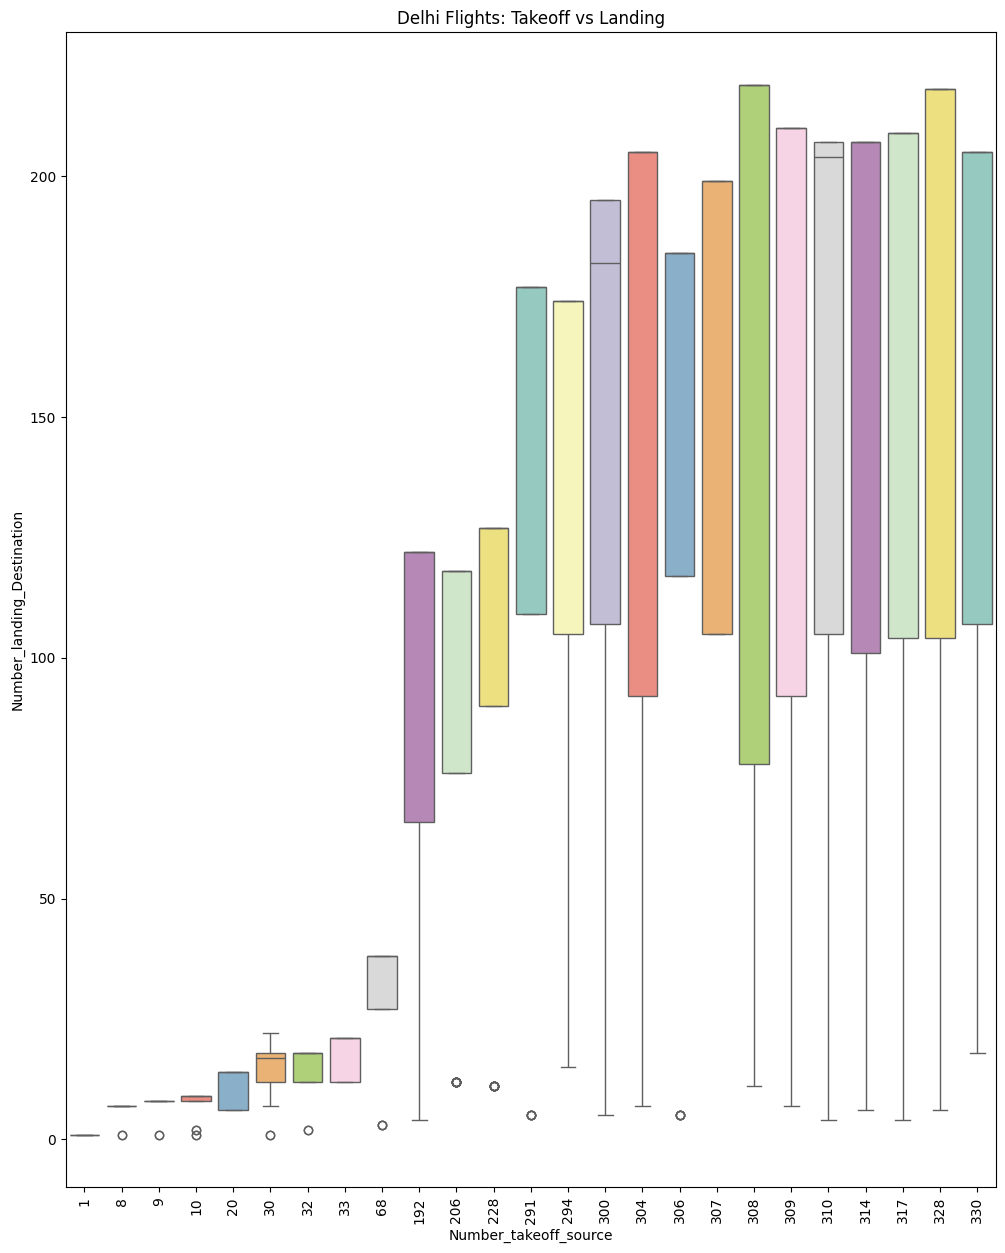

In [52]:

plt.figure(figsize=(12,15))

df_delhi = train[train["Source"] == "Delhi"]

sns.boxplot(
    data=df_delhi,
    x="Number_takeoff_source",
    y="Number_landing_Destination",
    palette="Set3"
)

plt.xticks(rotation=90)
plt.title("Delhi Flights: Takeoff vs Landing")
plt.show()

# Data Rescaling (Normalization)

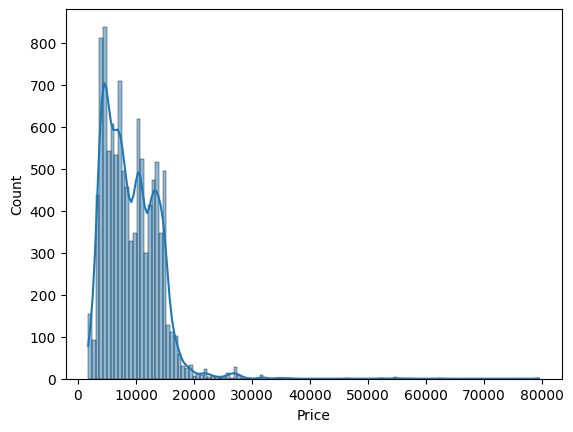

((array([-3.82690953, -3.60266143, -3.4795895 , ...,  3.4795895 ,
          3.60266143,  3.82690953]),
  array([ 1759.,  1759.,  1759., ..., 57209., 62427., 79512.])),
 (np.float64(4364.062692425855),
  np.float64(9087.064120565383),
  np.float64(0.9460976378917301)))

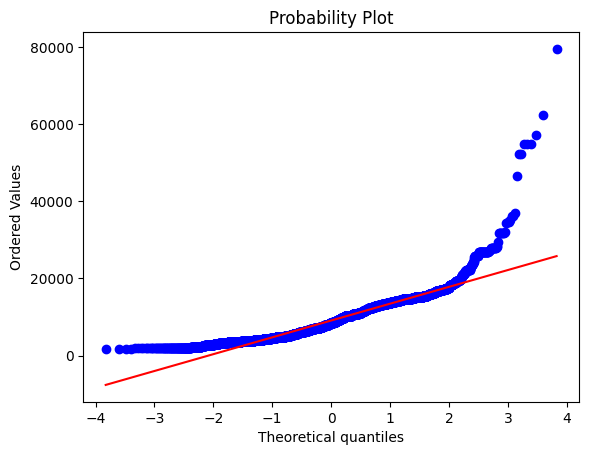

In [54]:
sns.histplot(train[:len_train].Price, kde=True)
l = plt.show()

stats.probplot(train[:len_train].Price, plot=plt)

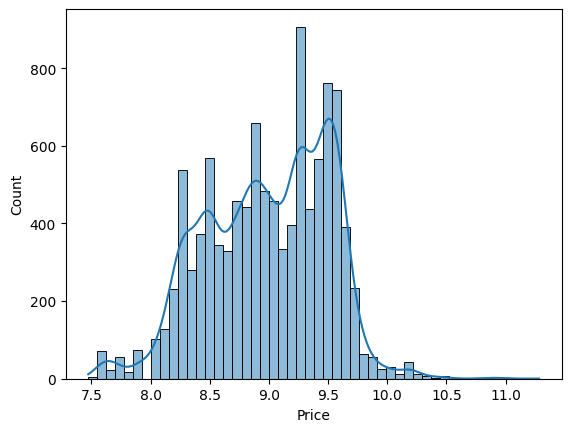

((array([-3.82690953, -3.60266143, -3.4795895 , ...,  3.4795895 ,
          3.60266143,  3.82690953]),
  array([ 7.47250074,  7.47250074,  7.47250074, ..., 10.95446651,
         11.04175315, 11.28366323])),
 (np.float64(0.50810528924744),
  np.float64(8.989144534386861),
  np.float64(0.988996119401397)))

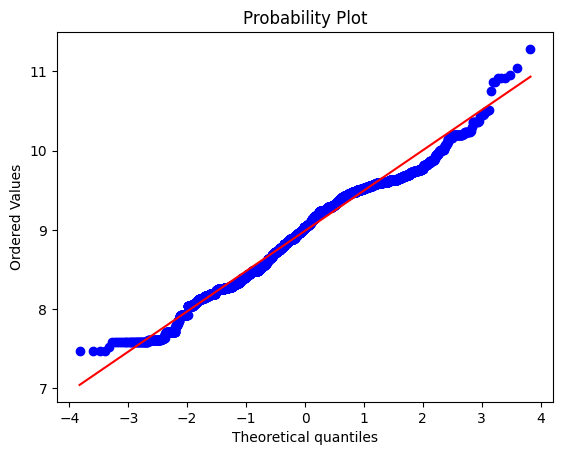

In [56]:
xt = np.log(train[:len_train].Price)

sns.histplot(xt, kde=True)
l = plt.show()

stats.probplot(xt, plot=plt)

# Handling Null Values

In [57]:
train.isnull().sum()

,0
Airline,0
Date_of_Journey,0
Source,0
Destination,0
Route,1
Dep_Time,0
Arrival_Time,0
Duration,0
Total_Stops,1
Additional_Info,0


In [65]:
# Step 1: Convert to datetime
train["Date_of_Journey"] = pd.to_datetime(train["Date_of_Journey"])

# Step 2: Apply filter
train.loc[
    (train.Source == 'Delhi') &
    (train.Destination == 'Cochin') &
    (train['Date_of_Journey'].dt.month == 5) &
    (train['Duration'].isna())
].head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Depart_Time_Hour,Depart_Time_Minutes,Arr_Time_Hour,Arr_Time_Minutes,Date_of_Arrival,Class,Same_day_travel,weekday_journey,weekday_arrival,Year,month_of_journey,month_of_Arrival,day_of_Arrival,day_of_Journey,Booking_Class,Market_Share,Number_take-offs,Number_landings,Number_takeoff_source,Number_landing_Destination


In [66]:
train.Route=train.Route.fillna('DEL -> MAA -> COK')
train.loc[train.Total_Stops.isnull(), 'Total_Stops']=1

# Removal of Outliers

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.776e+10, tolerance: 2.271e+07 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(


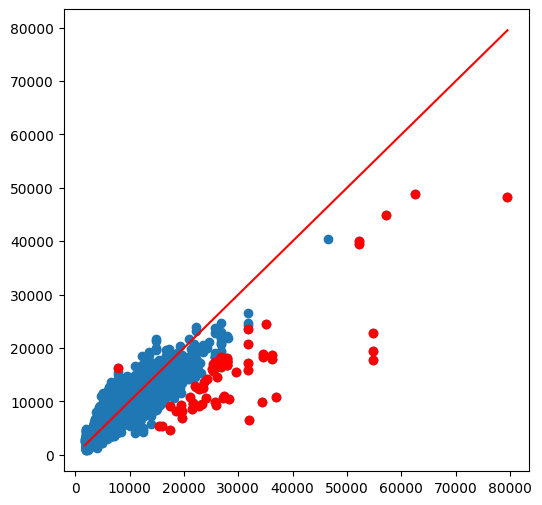

In [71]:

x_out = pd.get_dummies(train[:len_train].drop(['Price','Date_of_Journey','Date_of_Arrival'], axis=1))
y_out = train[:len_train].Price

# 🔥 FIX (important)
x_out = x_out.fillna(0)
y_out = y_out.fillna(0)

enet = ElasticNet(max_iter=1000, alpha=0.001, l1_ratio=0)

enet.fit(x_out, y_out)
y_pred = enet.predict(x_out)

resid = y_out - y_pred
z = (resid - resid.mean()) / resid.std()
z = np.array(z)

outlier = np.where(abs(z) > abs(z).std() * 5)[0]

plt.figure(figsize=(6, 6))
plt.scatter(y_out, y_pred)
plt.scatter(y_out.iloc[outlier], y_pred[outlier], color='red')

plt.plot([y_out.min(), y_out.max()], [y_out.min(), y_out.max()], color='red')
plt.show()

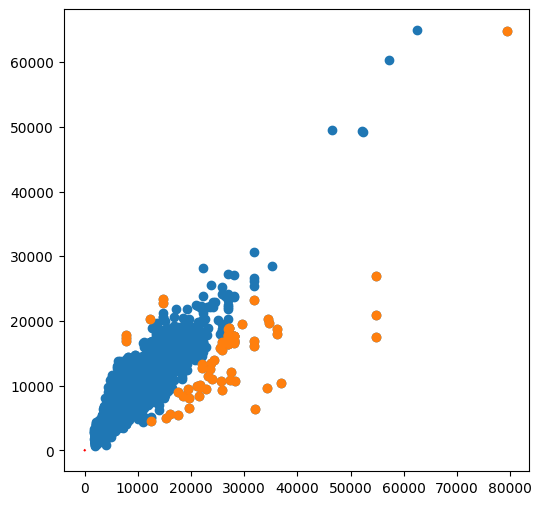

In [72]:
ridge=Ridge(alpha=1)

ridge.fit(x_out, y_out)
y_pred = ridge.predict(x_out)
resid=y_out-y_pred
z=(resid-resid.mean())/resid.std()
z=np.array(z)
outlier2=np.where(abs(z)>abs(z).std()*5)[0]
len(outlier2)

plt.figure(figsize=(6, 6))
plt.scatter(y_out, y_pred)
plt.scatter(y_out.iloc[outlier2], y_pred[outlier2])
plt.plot(range(7,12), range(7,12), color='red')

In [73]:
outlier_final=[]
for i in outlier:
  for j in outlier2:
    if i==j:
      outlier_final.append(i)
(outlier_final)

[np.int64(123),
 np.int64(268),
 np.int64(396),
 np.int64(486),
 np.int64(510),
 np.int64(515),
 np.int64(628),
 np.int64(826),
 np.int64(946),
 np.int64(1246),
 np.int64(1341),
 np.int64(1466),
 np.int64(1478),
 np.int64(1629),
 np.int64(1654),
 np.int64(1785),
 np.int64(1918),
 np.int64(1942),
 np.int64(2099),
 np.int64(2108),
 np.int64(2618),
 np.int64(2628),
 np.int64(2635),
 np.int64(2924),
 np.int64(3257),
 np.int64(3535),
 np.int64(4012),
 np.int64(4158),
 np.int64(4284),
 np.int64(4829),
 np.int64(5136),
 np.int64(5162),
 np.int64(5387),
 np.int64(5388),
 np.int64(5439),
 np.int64(5662),
 np.int64(5701),
 np.int64(5719),
 np.int64(5745),
 np.int64(5850),
 np.int64(5856),
 np.int64(5986),
 np.int64(6314),
 np.int64(6526),
 np.int64(6588),
 np.int64(6605),
 np.int64(6991),
 np.int64(7356),
 np.int64(7377),
 np.int64(7392),
 np.int64(7537),
 np.int64(7617),
 np.int64(7713),
 np.int64(7756),
 np.int64(8470),
 np.int64(8598),
 np.int64(8937),
 np.int64(8940),
 np.int64(9055),
 np.in

In [74]:
train.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Depart_Time_Hour,Depart_Time_Minutes,Arr_Time_Hour,Arr_Time_Minutes,Date_of_Arrival,Class,Same_day_travel,weekday_journey,weekday_arrival,Year,month_of_journey,month_of_Arrival,day_of_Arrival,day_of_Journey,Booking_Class,Market_Share,Number_take-offs,Number_landings,Number_takeoff_source,Number_landing_Destination
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,22:20:00,01:10:00,170,0.0,No info,3897.0,22,20,1,10,2019-03-24,Economy,0 days,6,6,2019,3,3,24,24,Economy,41.3,401,195,123,91
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50:00,13:15:00,445,2.0,No info,7662.0,5,50,13,15,2019-05-01,Economy,0 days,2,2,2019,5,5,1,1,Economy,13.5,339,148,226,62
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,09:25:00,04:25:00,1140,2.0,No info,13882.0,9,25,4,25,2019-06-09,Economy,0 days,6,6,2019,6,6,9,9,Ecocnomy,17.8,614,254,291,109
3,IndiGo,2019-05-12,Kolkata,Banglore,CCU → NAG → BLR,18:05:00,23:30:00,325,1.0,No info,6218.0,18,5,23,30,2019-05-13,Economy,1 days,6,0,2019,5,5,13,12,Economy,41.3,327,160,222,146
4,IndiGo,2019-03-01,Banglore,New Delhi,BLR → NAG → DEL,16:50:00,21:35:00,285,1.0,No info,13302.0,16,50,21,35,2019-03-02,Economy,1 days,4,5,2019,3,3,2,1,Economy,41.3,245,125,186,113


# Data Transformation (BOXCOX Transform)

In [75]:
numeric_dtypes = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
numerics2 = []
for i in train.columns:
  if i!='Price':
    if train[i].dtype in numeric_dtypes:
      numerics2.append(i)

skew_features = train[numerics2].apply(lambda x: skew(x)).sort_values(ascending=False)
skews = pd.DataFrame({'skew': skew_features})
print(skews)

high_skew = skew_features[abs(skew_features) > 0.3]
high_skew = high_skew
skew_index = high_skew.index

for i in skew_index:
  if i!='=Price':
    train[i] = boxcox1p(train[i], boxcox_normmax(train[i] + 1))


skew_features2 = train[numerics2].apply(lambda x: skew(x)).sort_values(ascending=False)
skew2 = pd.DataFrame({'skew': skew_features2})
skew2

/tmp/ipykernel_6835/184752038.py:8: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  skew_features = train[numerics2].apply(lambda x: skew(x)).sort_values(ascending=False)


                                skew
Duration                    0.867995
Number_landing_Destination  0.236348
Depart_Time_Minutes         0.159379
day_of_Journey              0.135127
day_of_Arrival              0.131884
Arr_Time_Minutes            0.111698
Depart_Time_Hour            0.109075
weekday_journey             0.040376
Number_landings             0.037367
weekday_arrival             0.012988
Number_takeoff_source      -0.348689
Arr_Time_Hour              -0.384548
month_of_Arrival           -0.390640
month_of_journey           -0.390640
Number_take-offs           -0.501536
Year                             NaN
Market_Share                     NaN


/tmp/ipykernel_6835/184752038.py:21: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  skew_features2 = train[numerics2].apply(lambda x: skew(x)).sort_values(ascending=False)


,skew
Number_landing_Destination,0.236348
Depart_Time_Minutes,0.159379
day_of_Journey,0.135127
day_of_Arrival,0.131884
Arr_Time_Minutes,0.111698
Depart_Time_Hour,0.109075
Duration,0.054899
weekday_journey,0.040376
Number_landings,0.037367
weekday_arrival,0.012988


# Data prepation for Modeling

In [106]:
train_model = train.drop(['Date_of_Journey','Date_of_Arrival'], axis=1)

# 🔥 separate target first
y = train_model[:len_train]['Price']

# 🔥 apply dummies only on features
df = pd.get_dummies(train_model.drop('Price', axis=1))

df.columns = df.columns.str.replace('[^A-Za-z0-9_]+', '', regex=True)
df.columns = [f"{col}_{i}" for i, col in enumerate(df.columns)]
train_df = df[:len_train]
test_df =df[len_train:]

In [109]:
x = train_df
x = x.fillna(0)
x = x.loc[:, ~x.columns.duplicated()]

# y already defined before

In [110]:
def rmsle_cv(model):
  kfold=KFold(n_splits=2, shuffle=True, random_state=10).get_n_splits(x)
  rmse=np.sqrt(-cross_val_score(model,x,y,cv=kfold, scoring='neg_mean_squared_error'))
  return rmse

In [111]:
lightgbm=LGBMRegressor(objective='regression',num_leaves=80,
                       learning_rate=0.1, n_estimators=1200,
                       max_bin=30, bagging_fraction =0.8,
                       bagging_freq =9, feature_fraction = 0.129,
                       feature_fraction_seed=9, bagging_seed=9,
                       min_data_in_leaf=3, min_sum_hessian_in_leaf=6, random_state=10)

In [112]:
rmsle_cv(lightgbm).mean(), rmsle_cv(lightgbm).std()

[LightGBM] [Warning] min_sum_hessian_in_leaf is set=6, min_child_weight=0.001 will be ignored. Current value: min_sum_hessian_in_leaf=6
[LightGBM] [Warning] min_data_in_leaf is set=3, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=3
[LightGBM] [Warning] bagging_freq is set=9, subsample_freq=0 will be ignored. Current value: bagging_freq=9
[LightGBM] [Warning] feature_fraction is set=0.129, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.129
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] min_sum_hessian_in_leaf is set=6, min_child_weight=0.001 will be ignored. Current value: min_sum_hessian_in_leaf=6
[LightGBM] [Warning] min_data_in_leaf is set=3, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=3
[LightGBM] [Warning] bagging_freq is set=9, subsample_freq=0 will be ignored. Current value: bagging_freq=9
[LightGBM] [Warning] featur

(np.float64(1539.4437941373253), np.float64(27.832104232918937))

In [113]:
xgb=XGBRegressor(learning_rate=0.1,
                 n_estimators=1500, max_depth=12, min_child_weight=1, gamma=0, reg_alpha=2e-5,
                 subsample=0.8, colsample_bytree=0.8,
                 nthread=4, scale_pos_weight=1,seed=27,verbose=True,random_state=10)

In [114]:
rmsle_cv(xgb).mean(),rmsle_cv(xgb).std()

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:58:14] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:58:42] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:59:06] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:59:33] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


(np.float64(1451.0844988653362), np.float64(14.743513941577703))

In [115]:
grb=GradientBoostingRegressor(n_estimators=400, learning_rate=0.01, max_depth=12,
                              subsample=0.8,verbose=False,random_state=10)

In [116]:
rmsle_cv(grb).mean(),rmsle_cv(grb).std()

(np.float64(1532.4975693247327), np.float64(1.3912839394829462))

In [117]:
svr = Pipeline([('Scaler',RobustScaler()), ('SVR', SVR(C=10000, epsilon=0.008, gamma=0.009))])

In [118]:
rmsle_cv(svr).mean(),rmsle_cv(svr).std()

(np.float64(2326.784765883169), np.float64(17.414035597708107))

In [120]:
krr = KernelRidge(alpha=1, kernel='polynomial', gamma=0.001, degree=3,coef0=5)
rmsle_cv(krr).mean(),rmsle_cv(krr).std()

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(


(np.float64(5041.398457350084), np.float64(43.66874993083229))

In [125]:
rf=RandomForestRegressor(n_estimators=100, oob_score=False, n_jobs=-1, random_state=50,
                         max_features='sqrt', min_samples_leaf =2, warm_start=True, criterion='squared_error', max_depth=50)

In [126]:
rmsle_cv(rf).mean(),rmsle_cv(rf).std()

(np.float64(1969.5381209047916), np.float64(21.13555368139282))

In [127]:
avg=StackingCVRegressor(regressors=(lightgbm,grb,svr,krr,rf),meta_regressor=xgb,use_features_in_secondary=True)

In [128]:
def rmsle(y,y_pred):
  return np.sqrt(mean_squared_error(y,y_pred))

In [129]:
X=np.array(x)
Y=np.array(y)

In [134]:
%%time
from sklearn.ensemble import StackingRegressor

stack = StackingRegressor(
    estimators=[
        ('rf', rf),
        ('lgbm', lightgbm)
    ],
    final_estimator=lightgbm
)

stack.fit(X, Y)
y_pred = stack.predict(X)

[LightGBM] [Warning] min_sum_hessian_in_leaf is set=6, min_child_weight=0.001 will be ignored. Current value: min_sum_hessian_in_leaf=6
[LightGBM] [Warning] min_data_in_leaf is set=3, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=3
[LightGBM] [Warning] bagging_freq is set=9, subsample_freq=0 will be ignored. Current value: bagging_freq=9
[LightGBM] [Warning] feature_fraction is set=0.129, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.129
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] min_sum_hessian_in_leaf is set=6, min_child_weight=0.001 will be ignored. Current value: min_sum_hessian_in_leaf=6
[LightGBM] [Warning] min_data_in_leaf is set=3, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=3
[LightGBM] [Warning] bagging_freq is set=9, subsample_freq=0 will be ignored. Current value: bagging_freq=9
[LightGBM] [Warning] featur

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] min_sum_hessian_in_leaf is set=6, min_child_weight=0.001 will be ignored. Current value: min_sum_hessian_in_leaf=6
[LightGBM] [Warning] min_data_in_leaf is set=3, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=3
[LightGBM] [Warning] bagging_freq is set=9, subsample_freq=0 will be ignored. Current value: bagging_freq=9
[LightGBM] [Warning] feature_fraction is set=0.129, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.129
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] min_sum_hessian_in_leaf is set=6, min_child_weight=0.001 will be ignored. Current value: min_sum_hessian_in_leaf=6
[LightGBM] [Warning] min_data_in_leaf is set=3, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=3
[LightGBM] [Warning] bagging_freq is set=9, subsample_freq=0 will be ignored. Current value: bagging_freq=9
[LightGBM] [Warning] featur

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] min_sum_hessian_in_leaf is set=6, min_child_weight=0.001 will be ignored. Current value: min_sum_hessian_in_leaf=6
[LightGBM] [Warning] min_data_in_leaf is set=3, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=3
[LightGBM] [Warning] bagging_freq is set=9, subsample_freq=0 will be ignored. Current value: bagging_freq=9
[LightGBM] [Warning] feature_fraction is set=0.129, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.129
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] min_sum_hessian_in_leaf is set=6, min_child_weight=0.001 will be ignored. Current value: min_sum_hessian_in_leaf=6
[LightGBM] [Warning] min_data_in_leaf is set=3, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=3
[LightGBM] [Warning] bagging_freq is set=9, subsample_freq=0 will be ignored. Current value: bagging_freq=9
[LightGBM] [Warning] featur

...

[LightGBM] [Warning] min_sum_hessian_in_leaf is set=6, min_child_weight=0.001 will be ignored. Current value: min_sum_hessian_in_leaf=6
[LightGBM] [Warning] min_data_in_leaf is set=3, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=3
[LightGBM] [Warning] bagging_freq is set=9, subsample_freq=0 will be ignored. Current value: bagging_freq=9
[LightGBM] [Warning] feature_fraction is set=0.129, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.129
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] min_sum_hessian_in_leaf is set=6, min_child_weight=0.001 will be ignored. Current value: min_sum_hessian_in_leaf=6
[LightGBM] [Warning] min_data_in_leaf is set=3, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=3
[LightGBM] [Warning] bagging_freq is set=9, subsample_freq=0 will be ignored. Current value: bagging_freq=9
[LightGBM] [Warning] featur

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] min_sum_hessian_in_leaf is set=6, min_child_weight=0.001 will be ignored. Current value: min_sum_hessian_in_leaf=6
[LightGBM] [Warning] min_data_in_leaf is set=3, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=3
[LightGBM] [Warning] bagging_freq is set=9, subsample_freq=0 will be ignored. Current value: bagging_freq=9
[LightGBM] [Warning] feature_fraction is set=0.129, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.129
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] min_sum_hessian_in_leaf is set=6, min_child_weight=0.001 will be ignored. Current value: min_sum_hessian_in_leaf=6
[LightGBM] [Warning] min_data_in_leaf is set=3, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=3
[LightGBM] [Warning] bagging_freq is set=9, subsample_freq=0 will be ignored. Current value: bagging_freq=9
[LightGBM] [Warning] feature_fraction is set=0.129, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.129
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
CPU times: user 1min 17s, sys: 1.5 s, total: 1min 19s
Wall time: 1min 10s


In [135]:
rmsle(Y,y_pred)

np.float64(1465.7913686817697)

# Applying Xgboost Model

In [147]:
from sklearn.ensemble import StackingRegressor

stack = StackingRegressor(
    estimators=[
        ('rf', rf),
        ('lgbm', lightgbm)
    ],
    final_estimator=lightgbm
)

stack.fit(X, Y)
y_pred = stack.predict(X)

[LightGBM] [Warning] min_sum_hessian_in_leaf is set=6, min_child_weight=0.001 will be ignored. Current value: min_sum_hessian_in_leaf=6
[LightGBM] [Warning] min_data_in_leaf is set=3, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=3
[LightGBM] [Warning] bagging_freq is set=9, subsample_freq=0 will be ignored. Current value: bagging_freq=9
[LightGBM] [Warning] feature_fraction is set=0.129, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.129
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] min_sum_hessian_in_leaf is set=6, min_child_weight=0.001 will be ignored. Current value: min_sum_hessian_in_leaf=6
[LightGBM] [Warning] min_data_in_leaf is set=3, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=3
[LightGBM] [Warning] bagging_freq is set=9, subsample_freq=0 will be ignored. Current value: bagging_freq=9
[LightGBM] [Warning] featur

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] min_sum_hessian_in_leaf is set=6, min_child_weight=0.001 will be ignored. Current value: min_sum_hessian_in_leaf=6
[LightGBM] [Warning] min_data_in_leaf is set=3, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=3
[LightGBM] [Warning] bagging_freq is set=9, subsample_freq=0 will be ignored. Current value: bagging_freq=9
[LightGBM] [Warning] feature_fraction is set=0.129, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.129
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] min_sum_hessian_in_leaf is set=6, min_child_weight=0.001 will be ignored. Current value: min_sum_hessian_in_leaf=6
[LightGBM] [Warning] min_data_in_leaf is set=3, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=3
[LightGBM] [Warning] bagging_freq is set=9, subsample_freq=0 will be ignored. Current value: bagging_freq=9
[LightGBM] [Warning] featur

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] min_sum_hessian_in_leaf is set=6, min_child_weight=0.001 will be ignored. Current value: min_sum_hessian_in_leaf=6
[LightGBM] [Warning] min_data_in_leaf is set=3, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=3
[LightGBM] [Warning] bagging_freq is set=9, subsample_freq=0 will be ignored. Current value: bagging_freq=9
[LightGBM] [Warning] feature_fraction is set=0.129, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.129
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] min_sum_hessian_in_leaf is set=6, min_child_weight=0.001 will be ignored. Current value: min_sum_hessian_in_leaf=6
[LightGBM] [Warning] min_data_in_leaf is set=3, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=3
[LightGBM] [Warning] bagging_freq is set=9, subsample_freq=0 will be ignored. Current value: bagging_freq=9
[LightGBM] [Warning] featur

...

[LightGBM] [Warning] min_sum_hessian_in_leaf is set=6, min_child_weight=0.001 will be ignored. Current value: min_sum_hessian_in_leaf=6
[LightGBM] [Warning] min_data_in_leaf is set=3, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=3
[LightGBM] [Warning] bagging_freq is set=9, subsample_freq=0 will be ignored. Current value: bagging_freq=9
[LightGBM] [Warning] feature_fraction is set=0.129, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.129
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] min_sum_hessian_in_leaf is set=6, min_child_weight=0.001 will be ignored. Current value: min_sum_hessian_in_leaf=6
[LightGBM] [Warning] min_data_in_leaf is set=3, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=3
[LightGBM] [Warning] bagging_freq is set=9, subsample_freq=0 will be ignored. Current value: bagging_freq=9
[LightGBM] [Warning] featur

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] min_sum_hessian_in_leaf is set=6, min_child_weight=0.001 will be ignored. Current value: min_sum_hessian_in_leaf=6
[LightGBM] [Warning] min_data_in_leaf is set=3, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=3
[LightGBM] [Warning] bagging_freq is set=9, subsample_freq=0 will be ignored. Current value: bagging_freq=9
[LightGBM] [Warning] feature_fraction is set=0.129, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.129
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] min_sum_hessian_in_leaf is set=6, min_child_weight=0.001 will be ignored. Current value: min_sum_hessian_in_leaf=6
[LightGBM] [Warning] min_data_in_leaf is set=3, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=3
[LightGBM] [Warning] bagging_freq is set=9, subsample_freq=0 will be ignored. Current value: bagging_freq=9
[LightGBM] [Warning] feature_fraction is set=0.129, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.129
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8


In [137]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold
from xgboost import XGBClassifier
from datetime import datetime
from sklearn.metrics import mean_squared_error

In [139]:
params = {
    'min_child_weight': [1, 5, 10],
    'gamma': [0.5, 1, 1.5, 2, 5],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'max_depth': [3, 4, 5]
}

In [ ]:
# xgb = XGBRegressor(learning_rate=0.02, n_estimators=2000)
# silent=True, nthread=1

In [140]:
def timer(start_time=None):
    if not start_time:
        start_time = datetime.now()
        return start_time
    elif start_time:
      thour, temp_sec = divmod((datetime.now() - start_time).total_seconds(), 3600)
      tmin, tsec = divmod(temp_sec, 60)
      print('\n Time taken: %i hours %i minutes and %s seconds.' %(thour, tmin, round(tsec, 2)))

In [141]:
folds = 3
param_comb = 2

random_search = RandomizedSearchCV(xgb, param_distributions=params, n_iter=param_comb, scoring=mean_squared_error, n_jobs=-1, cv=folds,verbose=1,random_state=10)
start_time = timer(None) # timing starts from this point for "start_time" variable
random_search.fit(X, Y)
timer(start_time) # timing ends here for "start_time" variable

Fitting 3 folds for each of 2 candidates, totalling 6 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan]
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:37:59] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



 Time taken: 0 hours 1 minutes and 20.49 seconds.


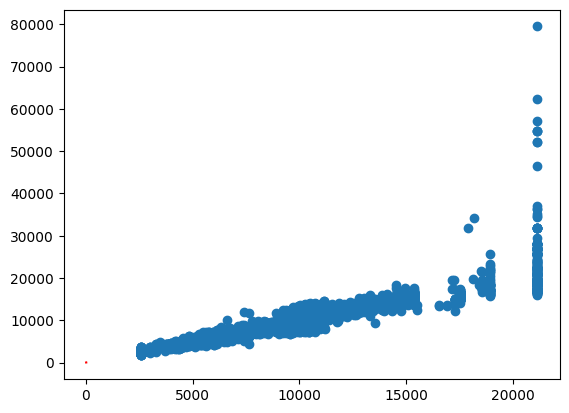

In [142]:
plt.scatter(list(y_pred),y)
plt.plot(range(7,13), range(7,13), 'r')

In [143]:
rmsle(y,y_pred)

np.float64(1465.7913686817697)

# Save the Model

In [154]:
import pickle

model = xgb
model.fit(X, Y)

# save model
with open('flight_price_model.pkl', 'wb') as file:
    pickle.dump(model, file)

print("Model saved successfully")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:26:30] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Model saved successfully


In [149]:
from google.colab import files
files.download('flight_price_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [150]:
import pickle

with open('flight_price_model.pkl', 'rb') as file:
    model = pickle.load(file)

# test
model.predict(X[:5])

array([ 4864.277 ,  7614.5596, 13890.336 ,  6465.279 , 13276.398 ],
      dtype=float32)